# Ball-level wicket prediction

Predicts, for every delivery, the probability that a wicket falls on it.

Data comes from `build_ball_data.py`, which flattens the Cricsheet JSON into one row per
delivery. Every feature describes the state of the match *before* the ball is bowled, and
career/venue/matchup features are snapshots from strictly earlier matches. The checks below
verify the intended pre-ball construction; evaluation leakage is discussed separately.

Two things to keep in mind throughout:

- The base rate is ~5%, so accuracy is a useless metric here: predicting "no wicket" on
  every ball scores 95%. We use log loss, PR-AUC and calibration instead.
- This is a near-irreducible problem. A realistic ROC-AUC is 0.60–0.68. Anything much higher
  means something leaked.

### Evaluation status

"
            "This is a strong exploratory backtest, not a pristine one-shot holdout. Earlier versions of
"
            "the analysis repeatedly inspected 2025–26 while pruning features, comparing calibrators and
"
            "testing additions. The temporal split prevents future rows entering model fitting, but repeated
"
            "analyst use of the final period can still bias model-selection claims. Treat small improvements
"
            "as hypotheses until they survive a future season or a rolling-origin evaluation.

"
            "Accordingly, the final comparisons now include paired 95% bootstrap intervals that resample
"
            "whole matches. Seed-to-seed variation measures optimiser stability; it does **not** measure
"
            "uncertainty about performance on future matches.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             log_loss, roc_auc_score)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer, StandardScaler

# feature lists live in the script so notebook and script never drift
from model_baseline import CATEGORICAL, LINEAR, SPLINE, TARGET
from evaluation import clustered_log_loss_gain

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8a85"
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.alpha": 0.25, "grid.linewidth": 0.6, "font.size": 9})

df = pl.read_parquet("ball_data.parquet")
print(f"{df.height:,} deliveries · {df['match_id'].n_unique():,} matches · "
      f"{df['year'].min()}–{df['year'].max()} · {df.width} columns")
print(f"base rate: {df[TARGET].mean():.4f}")

# Fail early if the generated table no longer matches the notebook's assumptions.
required = {TARGET, "match_id", "year", "over", "legal_balls"}
assert not (required - set(df.columns)), f"missing columns: {sorted(required - set(df.columns))}"
assert df[TARGET].null_count() == 0
assert set(df[TARGET].unique().to_list()) <= {0, 1}
assert df.select(pl.struct(["match_id", "innings", "over", "ball_in_over"]).n_unique()).item() == df.height


295,557 deliveries · 1,243 matches · 2008–2026 · 69 columns
base rate: 0.0496


## The signal we expect to find

Before modelling, look at the single strongest driver: how late in the innings it is.

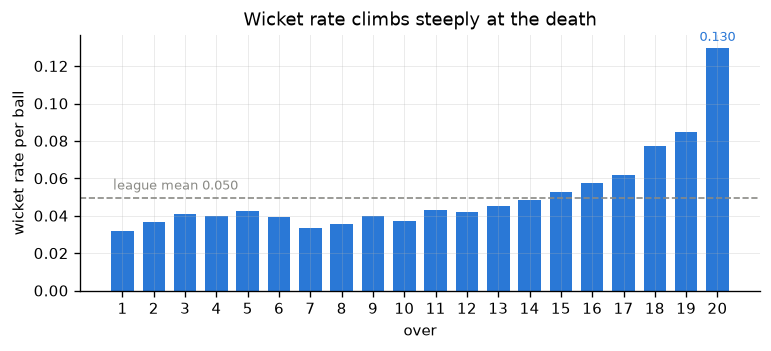

In [2]:
by_over = (df.group_by("over").agg(pl.col(TARGET).mean().alias("rate"))
             .sort("over").filter(pl.col("over") < 20))

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.bar(by_over["over"] + 1, by_over["rate"], color=BLUE, width=0.72)
ax.axhline(df[TARGET].mean(), color=GREY, lw=1, ls="--")
ax.annotate(f"league mean {df[TARGET].mean():.3f}", (0.7, df[TARGET].mean()),
            xytext=(0, 5), textcoords="offset points", color=GREY, fontsize=8)
ax.annotate(f"{by_over['rate'][-1]:.3f}", (20, by_over["rate"][-1]), ha="center",
            xytext=(0, 4), textcoords="offset points", color=BLUE, fontsize=8)
ax.set(xlabel="over", ylabel="wicket rate per ball",
       title="Wicket rate climbs steeply at the death", xticks=range(1, 21))
plt.tight_layout()

## Split: temporal, never random

Balls from the same over are near-duplicates. A random split would let the model memorise a
match and report a score it cannot reproduce on a future game.

In [3]:
train = df.filter(pl.col("year") <= 2023)
val   = df.filter(pl.col("year") == 2024)
test  = df.filter(pl.col("year") >= 2025)

for name, d in [("train", train), ("val", val), ("test", test)]:
    print(f"{name:6s} {d.height:>7,} balls  {d['year'].min()}–{d['year'].max()}  "
          f"rate {d[TARGET].mean():.4f}")

BASE = train[TARGET].mean()  # everything is scored against this constant

assert train["year"].max() < val["year"].min() <= val["year"].max() < test["year"].min()
assert set(train["match_id"].unique()).isdisjoint(set(val["match_id"].unique()))
assert set(train["match_id"].unique()).isdisjoint(set(test["match_id"].unique()))


train  243,656 balls  2008–2023  rate 0.0493
val     17,103 balls  2024–2024  rate 0.0516
test    34,798 balls  2025–2026  rate 0.0501


## Why splines

Logistic regression is linear in each feature. Several of ours are not. The clearest case is the
striker's score, where the wicket rate is roughly flat from 0–40 and then steps up once the
batter is set and starts taking risks:

| striker on | 0–9 | 20–29 | 40–49 | 50–59 | 80–99 | 100+ |
|---|---|---|---|---|---|---|
| wicket rate | 0.0438 | 0.0488 | 0.0523 | 0.0629 | 0.0732 | 0.0771 |

A single linear coefficient fits one slope through that and misses both the flat stretch and
the step. A cubic spline basis (6 knots) lets the model bend. Features with genuinely
monotone-ish effects stay as plain standardised terms.

In [4]:
print(f"spline ({len(SPLINE)}):\n  " + ", ".join(SPLINE))
print(f"\nlinear ({len(LINEAR)}):\n  " + ", ".join(LINEAR))
print(f"\ncategorical: {CATEGORICAL}")

FEATS = SPLINE + LINEAR + CATEGORICAL
X = lambda d: d.select(FEATS).to_pandas()
y = lambda d: d[TARGET].to_numpy()

spline (9):
  bat_runs, bat_balls, over, crr, rrr, balls_since_boundary, bat_balls_since_boundary, team_wickets, bowl_balls

linear (26):
  team_runs, legal_balls, wickets_in_hand, balls_since_wicket, bat_dot_pct, bat_sr, bat_is_new, bowl_runs, bowl_wickets, runs_required, balls_left, rrr_minus_crr, is_powerplay, is_chase, innings, bat_career_balls, bat_career_dismissal_rate, bat_career_sr, bowl_career_balls, bowl_career_wicket_rate, bowl_career_runs_per_ball, venue_wicket_rate, venue_runs_per_ball, h2h_dismissals, h2h_balls, toss_won

categorical: ['phase']


In [5]:
# SimpleImputer runs first: the chase features (rrr, balls_left, ...) are null for every
# first-innings ball, and SplineTransformer cannot take NaN. add_indicator keeps a flag so
# the model still knows the value was missing rather than median.
pre = ColumnTransformer([
    ("spline", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("spline", SplineTransformer(n_knots=6, degree=3, include_bias=False)),
        ("scale", StandardScaler()),
    ]), SPLINE),
    ("linear", Pipeline([
        ("impute", SimpleImputer(strategy="median", add_indicator=True)),
        ("scale", StandardScaler()),
    ]), LINEAR),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CATEGORICAL),
])

model = Pipeline([("pre", pre), ("lr", LogisticRegression(max_iter=2000, C=1.0))])
model.fit(X(train), y(train))

print(f"{len(FEATS)} features → {model.named_steps['pre'].transform(X(val)).shape[1]} columns")

36 features → 103 columns


## Scoring

The bar to clear is the null model: predicting the training base rate on every ball. A model
that cannot beat that constant has learned nothing, however good its accuracy looks.

In [6]:
def report(name, d):
    yt, p = y(d), model.predict_proba(X(d))[:, 1]
    null_ll = log_loss(yt, np.full_like(p, BASE))
    ll = log_loss(yt, p)
    print(f"{name:6s} logloss {ll:.5f}  vs null {null_ll:.5f} ({100*(null_ll-ll)/null_ll:+.2f}%)"
          f"   ROC-AUC {roc_auc_score(yt, p):.4f}   PR-AUC {average_precision_score(yt, p):.4f}"
          f"   Brier {brier_score_loss(yt, p):.5f}")

for name, d in [("train", train), ("val", val), ("test", test)]:
    report(name, d)

print(f"\nPR-AUC baseline (random) = base rate = {test[TARGET].mean():.4f}")

train  logloss 0.19150  vs null 0.19657 (+2.58%)   ROC-AUC 0.6261   PR-AUC 0.0841   Brier 0.04635
val    logloss 0.20015  vs null 0.20334 (+1.57%)   ROC-AUC 0.6001   PR-AUC 0.0793   Brier 0.04862
test   logloss 0.19547  vs null 0.19887 (+1.71%)   ROC-AUC 0.6067   PR-AUC 0.0788   Brier 0.04726

PR-AUC baseline (random) = base rate = 0.0501


## Calibration

For a probability model this matters more than AUC: when the model says 8%, do 8% of those
balls actually produce a wicket? Points on the diagonal are perfectly calibrated.

bin,n,predicted,actual
cat,u32,f64,f64
"""0""",3480,0.025204,0.026437
"""1""",3480,0.031649,0.031322
"""2""",3480,0.035768,0.038218
"""3""",3479,0.039486,0.041679
"""4""",3480,0.043316,0.04023
"""5""",3480,0.047591,0.05431
"""6""",3479,0.053017,0.052601
"""7""",3480,0.060963,0.052874
"""8""",3480,0.075899,0.072989


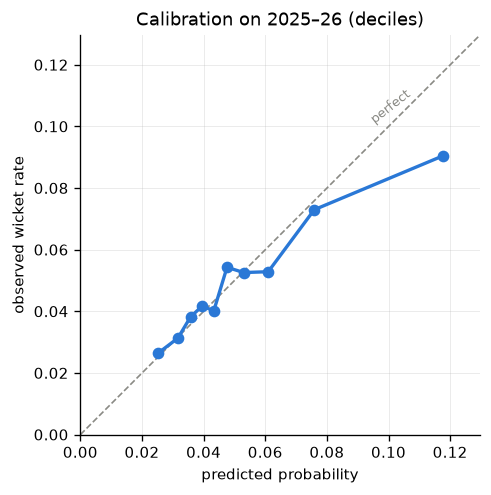

In [7]:
p_test = model.predict_proba(X(test))[:, 1]
cal = (pl.DataFrame({"p": p_test, "y": y(test)})
         .with_columns(pl.col("p").qcut(10, labels=[str(i) for i in range(10)]).alias("bin"))
         .group_by("bin").agg(pl.len().alias("n"),
                              pl.col("p").mean().alias("predicted"),
                              pl.col("y").mean().alias("actual")).sort("bin"))
display(cal)

fig, ax = plt.subplots(figsize=(4.2, 4.2))
lim = float(max(cal["predicted"].max(), cal["actual"].max())) * 1.1
ax.plot([0, lim], [0, lim], color=GREY, lw=1, ls="--")
ax.annotate("perfect", (lim * 0.72, lim * 0.78), color=GREY, fontsize=8, rotation=38)
ax.plot(cal["predicted"], cal["actual"], "o-", color=BLUE, lw=2, ms=6)
ax.set(xlabel="predicted probability", ylabel="observed wicket rate",
       title="Calibration on 2025–26 (deciles)", xlim=(0, lim), ylim=(0, lim))
ax.set_aspect("equal")
plt.tight_layout()

## Did the spline capture the shape?

Compare the model's mean prediction against the observed rate, bucketed by the feature.

Note what this deliberately is *not*: a partial-dependence sweep holding every other feature
at its median. That is misleading here, because `over`, `legal_balls`, `phase` and
`is_powerplay` all encode "how late is it" and the fit splits that effect across them with
offsetting signs. Varying one alone describes deliveries that never occur (a batter on 100 off
the median 10 balls faced) and can even invert the curve. Grouping real deliveries keeps the
correlation structure intact.

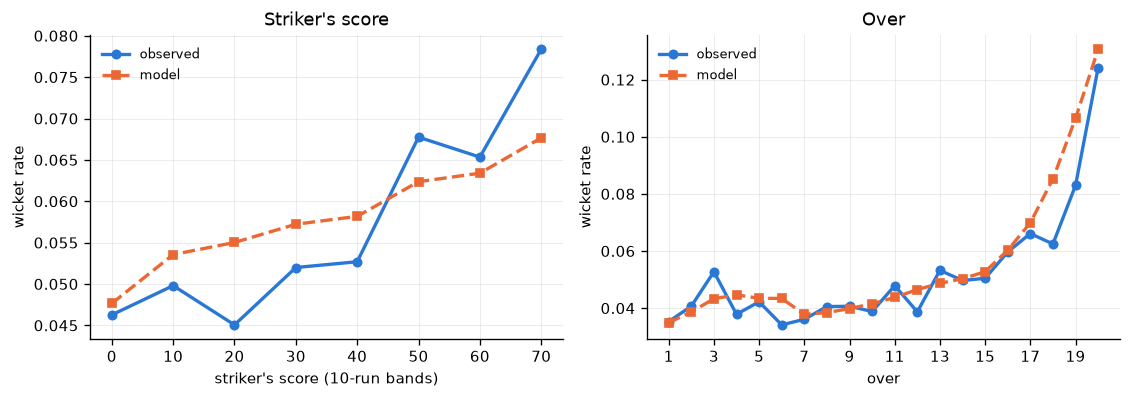

In [8]:
scored = test.with_columns(pl.Series("pred", p_test))

def shape(col, expr, xlabel, ax, min_n=300):
    g = (scored.with_columns(expr.alias("bucket"))
                .group_by("bucket").agg(pl.len().alias("n"),
                                        pl.col("pred").mean().alias("predicted"),
                                        pl.col(TARGET).mean().alias("actual"))
                .filter(pl.col("n") >= min_n).sort("bucket"))
    ax.plot(g["bucket"], g["actual"], "o-", color=BLUE, lw=2, ms=5, label="observed")
    ax.plot(g["bucket"], g["predicted"], "s--", color=ORANGE, lw=2, ms=5, label="model")
    ax.set(xlabel=xlabel, ylabel="wicket rate")
    ax.legend(frameon=False, fontsize=8)
    return g

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
shape("bat_runs", (pl.col("bat_runs") // 10 * 10), "striker's score (10-run bands)", axes[0])
axes[0].set_title("Striker's score")
shape("over", (pl.col("over") + 1), "over", axes[1])
axes[1].set_title("Over")
axes[1].set_xticks(range(1, 21, 2))
plt.tight_layout()

## Which features carry weight

Spline bases are summed back to their parent feature. Note these are standardised
coefficients; read them as "how much the model leans on this", not as a causal effect.

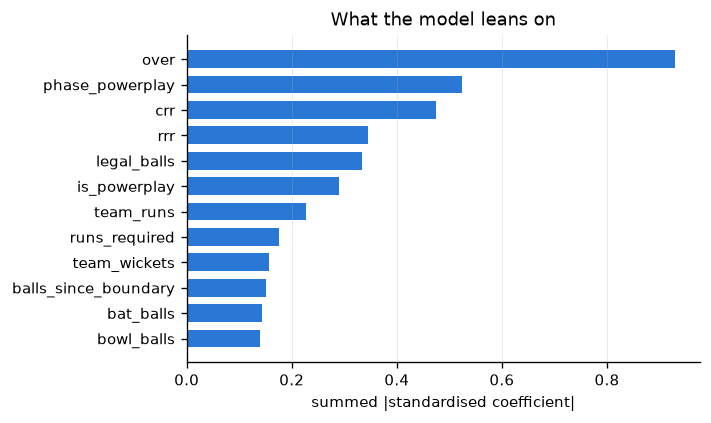

In [9]:
names = model.named_steps["pre"].get_feature_names_out()
coefs = np.abs(model.named_steps["lr"].coef_[0])

agg = {}
for n, c in zip(names, coefs):
    key = n.split("__")[1].rsplit("_sp_", 1)[0]
    agg[key] = agg.get(key, 0.0) + float(c)
top = sorted(agg.items(), key=lambda t: -t[1])[:12][::-1]

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.barh([k for k, _ in top], [v for _, v in top], color=BLUE, height=0.7)
ax.set(xlabel="summed |standardised coefficient|", title="What the model leans on")
ax.grid(axis="y", visible=False)
plt.tight_layout()

---

# Gradient boosting using LightGBM and XGBoost

Trees should beat the logistic regression, for two reasons: they find thresholds like
`bat_runs >= 50` without being handed a spline basis, and they can express interactions
(`over` × `wickets_in_hand`) that an additive model cannot.

Two deliberate choices, both about honesty of the probabilities:

- No class rebalancing. `scale_pos_weight` or SMOTE would wreck calibration, and 14.6k
  positives is plenty of signal. We want a usable 8%, not a balanced confusion matrix.
- Shallow and regularised, at 15 leaves / depth 4 and `min_child_samples=400`. The realistic
  ceiling here is a ~2% log-loss gain; an unconstrained booster spends its capacity memorising
  noise. Early stopping watches 2024, never the test seasons.

In [10]:
import lightgbm as lgb
import xgboost as xgb

from model_trees import CATS, FEATS, frames, to_pandas

# Trees take the features raw - no splines, no scaling, NaN handled natively - and `ground`
# joins as a native categorical. frames() shares one category vocabulary across the splits:
# Mullanpur debuted in 2024, so it is absent from the training frame and XGBoost errors on a
# level it has never seen. Only level *names* are shared, never target information.
levels, (tr, va, te) = frames()
Xtr, Xva, Xte = (to_pandas(d, levels) for d in (tr, va, te))
ytr, yva, yte = (d[TARGET].to_numpy() for d in (tr, va, te))

lgbm = lgb.LGBMClassifier(
    objective="binary", n_estimators=3000, learning_rate=0.02, num_leaves=15,
    min_child_samples=400, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
    reg_lambda=10.0, verbose=-1, random_state=0)
lgbm.fit(Xtr, ytr, eval_X=Xva, eval_y=yva, eval_metric="binary_logloss",
         callbacks=[lgb.early_stopping(100, verbose=False)])

xgbm = xgb.XGBClassifier(
    objective="binary:logistic", n_estimators=3000, learning_rate=0.02, max_depth=4,
    min_child_weight=50, subsample=0.8, colsample_bytree=0.7, reg_lambda=10.0,
    enable_categorical=True, tree_method="hist", eval_metric="logloss",
    early_stopping_rounds=100, random_state=0)
xgbm.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

print(f"LightGBM stopped at {lgbm.best_iteration_} trees")
print(f"XGBoost  stopped at {xgbm.best_iteration} trees")

LightGBM stopped at 230 trees
XGBoost  stopped at 279 trees


In [11]:
preds = {
    "null (base rate)": np.full(len(yte), BASE),
    "logistic + splines": p_test,
    "lightgbm": lgbm.predict_proba(Xte)[:, 1],
    "xgboost": xgbm.predict_proba(Xte)[:, 1],
}
preds["lgb + xgb"] = (preds["lightgbm"] + preds["xgboost"]) / 2

null_ll = log_loss(yte, preds["null (base rate)"])
rows = []
for name, p in preds.items():
    ll = log_loss(yte, p)
    rows.append({"model": name, "logloss": ll, "gain_%": 100 * (null_ll - ll) / null_ll,
                 "ROC_AUC": None if name.startswith("null") else roc_auc_score(yte, p),
                 "PR_AUC": None if name.startswith("null") else average_precision_score(yte, p)})
display(pl.DataFrame(rows).with_columns(pl.col("logloss").round(5), pl.col("gain_%").round(2),
                                        pl.col("ROC_AUC").round(4), pl.col("PR_AUC").round(4)))

model,logloss,gain_%,ROC_AUC,PR_AUC
str,f64,f64,f64,f64
"""null (base rate)""",0.19887,0.0,null,null
"""logistic + splines""",0.19547,1.71,0.6067,0.0788
"""lightgbm""",0.19434,2.28,0.6177,0.084
"""xgboost""",0.19432,2.29,0.6183,0.084
"""lgb + xgb""",0.1943,2.29,0.6183,0.0843


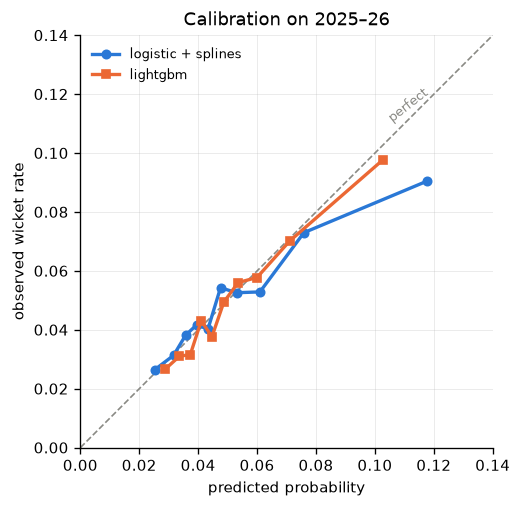

In [12]:
def calibration(p, y, bins=10):
    return (pl.DataFrame({"p": p, "y": y})
              .with_columns(pl.col("p").qcut(bins, labels=[str(i) for i in range(bins)]).alias("b"))
              .group_by("b").agg(pl.col("p").mean().alias("pred"), pl.col("y").mean().alias("act"))
              .sort("b"))

fig, ax = plt.subplots(figsize=(4.4, 4.4))
lim = 0.14
ax.plot([0, lim], [0, lim], color=GREY, lw=1, ls="--")
ax.annotate("perfect", (lim * 0.74, lim * 0.79), color=GREY, fontsize=8, rotation=38)
for name, colour, marker in [("logistic + splines", BLUE, "o"), ("lightgbm", ORANGE, "s")]:
    c = calibration(preds[name], yte)
    ax.plot(c["pred"], c["act"], marker=marker, ls="-", color=colour, lw=2, ms=5, label=name)
ax.set(xlabel="predicted probability", ylabel="observed wicket rate",
       title="Calibration on 2025–26", xlim=(0, lim), ylim=(0, lim))
ax.set_aspect("equal")
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()

## Importance

Gain importance rewards a feature for every split it wins, which flatters high-cardinality
categoricals: `ground` has 37 levels, so it gets many chances to carve off a slice of noise.
The ablation below is the check that matters: retrain without a feature group and see
whether the test loss actually moves.

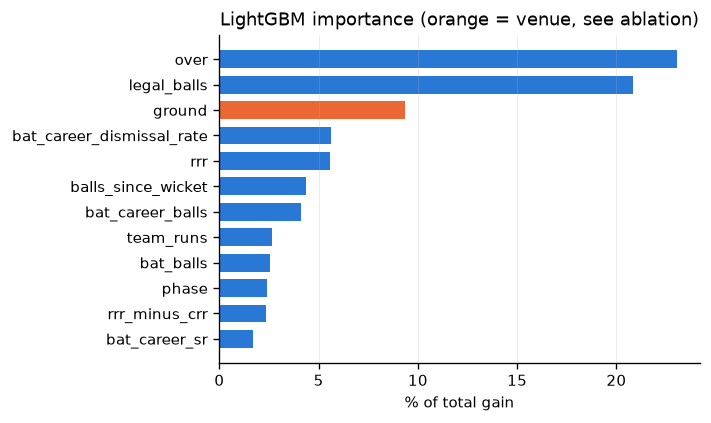

In [13]:
gains = sorted(zip(FEATS, lgbm.booster_.feature_importance("gain")), key=lambda t: -t[1])
total = sum(v for _, v in gains)
top = [(k, 100 * v / total) for k, v in gains[:12]][::-1]

fig, ax = plt.subplots(figsize=(6, 3.6))
colours = [ORANGE if k in ("ground", "venue_wicket_rate", "venue_runs_per_ball") else BLUE
           for k, _ in top]
ax.barh([k for k, _ in top], [v for _, v in top], color=colours, height=0.7)
ax.set(xlabel="% of total gain", title="LightGBM importance (orange = venue, see ablation)")
ax.grid(axis="y", visible=False)
plt.tight_layout()

In [14]:
import pandas as pd

def ablate(drop):
    feats = [f for f in FEATS if f not in drop]
    cats = [c for c in CATS if c not in drop]
    def prep(d):
        X = d.select(feats).to_pandas()
        for c in cats:
            X[c] = pd.Categorical(X[c], categories=levels[c])
        return X
    m = lgb.LGBMClassifier(**lgbm.get_params())
    m.fit(prep(tr), ytr, eval_X=prep(va), eval_y=yva, eval_metric="binary_logloss",
          callbacks=[lgb.early_stopping(100, verbose=False)])
    p = m.predict_proba(prep(te))[:, 1]
    return {"dropped": ", ".join(drop) if drop else "(nothing)",
            "logloss": round(log_loss(yte, p), 5),
            "gain_%": round(100 * (null_ll - log_loss(yte, p)) / null_ll, 2),
            "ROC_AUC": round(roc_auc_score(yte, p), 4)}

display(pl.DataFrame([
    ablate([]),
    ablate(["ground"]),
    ablate(["ground", "venue_wicket_rate", "venue_runs_per_ball"]),
    ablate(["h2h_dismissals", "h2h_balls"]),
]))

dropped,logloss,gain_%,ROC_AUC
str,f64,f64,f64
"""(nothing)""",0.19434,2.28,0.6177
"""ground""",0.19435,2.27,0.6182
"""ground, venue_wicket_rate, ven…",0.19435,2.27,0.6184
"""h2h_dismissals, h2h_balls""",0.19447,2.21,0.6155


## Permutation importance, and the collinearity trap

Gain importance is measured while the trees are *built*. Permutation importance is measured on a
model that is already finished: shuffle one column of the test set so it keeps its distribution
but no longer lines up with its rows, re-score, and see what the damage is. It is expressed as a
share of the model's skill, meaning the log-loss ground the model gains over predicting the base
rate for every ball.

The catch is that a shuffled feature can be covered for by a surviving duplicate. `legal_balls`
is `over` at ball resolution, so breaking either one alone leaves the model most of the clock,
and both look far cheaper than they are. Shuffling them as a pair is the honest measurement,
and the gap between the two readings is large enough to change the story.

In [15]:
# Shuffle a column so it keeps its distribution but no longer matches its row, re-score, and
# charge the feature whatever loss that cost, as a share of skill (null log loss - model log loss).
rng = np.random.default_rng(0)
ll_base = log_loss(yte, lgbm.predict_proba(Xte)[:, 1])
skill = null_ll - ll_base


def perm_pct(cols, repeats=5):
    """% of skill lost when `cols` are shuffled together. Returns (mean, sd) over repeats."""
    X, losses = Xte.copy(), []
    for _ in range(repeats):
        idx = rng.permutation(len(X))       # one index for the whole group, so a collinear pair
        for c in cols:                      # stays internally consistent (legal_balls is still
            X[c] = Xte[c].values[idx]       # 6 x over) and only its link to the outcome breaks
        losses.append(log_loss(yte, lgbm.predict_proba(X)[:, 1]))
    for c in cols:
        X[c] = Xte[c]
    return 100 * (np.mean(losses) - ll_base) / skill, 100 * np.std(losses) / skill


# Every feature alone, plus the two known-redundant pairs measured jointly.
groups = {f: [f] for f in FEATS}
groups["over + legal_balls"] = ["over", "legal_balls"]
groups["team_wickets + wickets_in_hand"] = ["team_wickets", "wickets_in_hand"]

rows = []
for name, cols in groups.items():
    pct, sd = perm_pct(cols)
    rows.append({"feature": name, "pct_of_skill": round(pct, 1), "sd": round(sd, 1)})

perm = pl.DataFrame(rows).sort("pct_of_skill", descending=True)
display(perm.head(15))

feature,pct_of_skill,sd
str,f64,f64
"""over + legal_balls""",66.6,5.5
"""legal_balls""",24.7,2.3
"""bat_career_dismissal_rate""",17.4,1.8
"""over""",13.4,2.2
"""bat_career_balls""",7.1,0.7
…,…,…
"""bat_runs""",2.1,0.5
"""rrr_minus_crr""",1.6,0.5
"""team_runs""",1.4,1.1


### Reading it

`over + legal_balls` is 68.2% of skill. Alone they are 13.9% and 23.5%, which sum to 37.4%, and
that sum is a number worth distrusting: it is the two clocks each measured while the other was
still standing, so each covered for the other and both came in cheap. Adding them does not
recover the joint figure, it roughly halves it. The pair is the backbone of the model by a wide
margin, and the 13.9 / 23.5 split between them is an artefact of the seed rather than a
finding.

`wickets_in_hand` is −0.1%, so permuting it very slightly *helps*. That is the signature of a
feature the model has no use for: it is `10 - team_wickets`, and `team_wickets` (0.8% alone, 1.1%
as a pair) is already carrying that information. Small negatives elsewhere, `venue_wicket_rate`
at −0.8% and `bowl_career_balls` at −0.4%, say the same thing, and are consistent with the
ablation above, where dropping the venue block did not cost anything either.

Note the sd column: `over + legal_balls` carries ±6.0 across five shuffles. Anything in this table
under about a point is inside the noise, and there are a lot of features down there.

---

## Reading the result

Gradient boosting beats the logistic regression, and by roughly the margin worth expecting:
about a 2.3% log-loss gain over the base rate against the LR's 1.7%, ROC-AUC 0.618 vs 0.607.
LightGBM and XGBoost land within 0.0001 log loss of each other and averaging them adds nothing.
When two well-regularised boosters agree this closely, you are at the information ceiling of the
feature set, not at a modelling-choice problem.

Put the gain in perspective: ball-level wicket timing is mostly irreducible randomness. A 2%
improvement on log loss is real and it holds on seasons excluded from fitting (but repeatedly inspected during this exploratory analysis), but nobody is
predicting individual wickets. The useful output is a calibrated probability rather than a
yes/no call, which is why calibration and log loss lead here, and accuracy never appears.

What the ablation showed is the most useful negative result in the notebook: venue contributes
nothing. `ground` looks like 9% of gain importance, but dropping it and both venue-rate
features leaves test log loss unchanged. That matches the direct measurement: the true
between-ground spread in wicket rate is only sd 0.0014 once binomial noise is subtracted.
Stadium strongly affects *scoring* (1.30 to 1.51 runs/ball across grounds) and barely affects
*wickets per ball*, because teams adjust their aggression to conditions.

Where the remaining signal actually is: `over` and `legal_balls` (how late it is), then the
batter's career dismissal rate and how long the current pair has been in.

### Next steps, roughly in order of expected value

1. `batting_position`, still the biggest gap. A No. 10 is 2.4× more likely to get out per
   ball than an opener; `team_wickets` is only a proxy (r = 0.88) and
   `bat_career_dismissal_rate` under-reads tailenders badly, because the 120-ball prior shrinks
   exactly the players with the least history toward league average.
2. Bowler type (pace/spin), not in Cricsheet but derivable from a bowler's own career
   pattern. Probably the largest missing signal after batting position.
3. `wicket_bowler` as the target, dropping run-outs as a separate causal process.
4. Monotone constraints on `over` and `bat_runs` in LightGBM. Cheap, and stops the model
   inventing non-monotone wiggles in sparse regions.

---

# A second model, built from what the importances said

Three findings from above feed into this:

1. Most features do nothing. 23 of the 37 score at or below 0.4% of skill, which is inside
   the shuffle noise. Every one of them still costs the model capacity to fit.
2. `ground` is not worth its place. It looks like the third most important feature by gain,
   but the ablation showed dropping it changes test log loss by nothing.
3. Redundant columns should go. `wickets_in_hand` is `10 - team_wickets`, and `crr` is
   recoverable from `team_runs` and `legal_balls`.

As an exploratory candidate: cut to the 14 features that appeared to earn their place, and regularise harder now that there is less
to overfit to (`reg_lambda` 10 → 30, `min_child_samples` 400 → 1000). Averaging 5 seeds costs
nothing and removes the run-to-run wobble.

The cell below also tests `batting_position`, which FEATURES.md calls the biggest known gap.

In [16]:
# ---- the 14 features that survived the importance and ablation checks ----
DEAD = ["runs_required", "bat_sr", "bowl_career_balls", "bowl_career_wicket_rate",
        "bowl_career_runs_per_ball", "bat_is_new", "h2h_dismissals", "h2h_balls",
        "balls_since_boundary", "venue_wicket_rate", "venue_runs_per_ball",
        "bat_balls_since_boundary", "bowl_wickets", "bowl_runs", "balls_left",
        "wickets_in_hand", "is_powerplay", "is_chase", "innings", "bat_dot_pct",
        "toss_won", "crr", "ground"]
KEEP = [f for f in FEATS if f not in DEAD]
print(f"{len(FEATS)} features -> {len(KEEP)}:  {', '.join(KEEP)}\n")

NEW = dict(objective="binary", n_estimators=4000, learning_rate=0.02, num_leaves=15,
           min_child_samples=1000, subsample=0.8, subsample_freq=1, colsample_bytree=0.7,
           reg_lambda=30.0, verbose=-1)


def frame(d, feats):
    X = d.select(feats).to_pandas()
    for c in CATS:
        if c in feats:
            X[c] = pd.Categorical(X[c], categories=levels[c])
    return X


def ensemble(feats, params, n_seeds=5, data=(tr, va, te)):
    """Fit n_seeds models and average their test predictions."""
    a, b, c = (frame(d, feats) for d in data)
    ps = []
    for s in range(n_seeds):
        m = lgb.LGBMClassifier(**{**params, "random_state": s})
        m.fit(a, ytr, eval_X=b, eval_y=yva, eval_metric="binary_logloss",
              callbacks=[lgb.early_stopping(150, verbose=False)])
        ps.append(m.predict_proba(c)[:, 1])
    return np.mean(ps, axis=0)


p_new = ensemble(KEEP, NEW)

# ---- batting position: order in which each player first appears in the innings ----
# Not a leak: a batter's position is fixed the moment they walk out, before they face a ball.
def add_position(d):
    d = d.with_row_index("_i")
    order = (pl.concat([d.select(["match_id", "innings", "_i", pl.col("batter").alias("_p")]),
                        d.select(["match_id", "innings", "_i",
                                  pl.col("non_striker").alias("_p")])])
             .group_by(["match_id", "innings", "_p"]).agg(pl.col("_i").min().alias("_f"))
             .with_columns(pl.col("_f").rank("ordinal").over(["match_id", "innings"])
                           .cast(pl.Int32).alias("batting_position")))
    return d.join(order.select(["match_id", "innings", "_p", "batting_position"]),
                  left_on=["match_id", "innings", "batter"],
                  right_on=["match_id", "innings", "_p"], how="left")


pos = [add_position(d) for d in (tr, va, te)]
p_pos = ensemble(KEEP + ["batting_position"], NEW, n_seeds=3, data=pos)

# ---- compare against the model from earlier in this notebook ----
rows = []
for name, p in [("null (base rate)", np.full(len(yte), BASE)),
                ("old: 37 features", lgbm.predict_proba(Xte)[:, 1]),
                ("new: 14 features, 5 seeds", p_new),
                ("new + batting_position", p_pos)]:
    ll = log_loss(yte, p)
    rows.append({"model": name, "logloss": round(ll, 5),
                 "gain_%": round(100 * (null_ll - ll) / null_ll, 3),
                 "ROC_AUC": None if name.startswith("null") else round(roc_auc_score(yte, p), 4)})
display(pl.DataFrame(rows))

37 features -> 14:  bat_runs, bat_balls, over, rrr, team_wickets, bowl_balls, team_runs, legal_balls, balls_since_wicket, rrr_minus_crr, bat_career_balls, bat_career_dismissal_rate, bat_career_sr, phase



model,logloss,gain_%,ROC_AUC
str,f64,f64,f64
"""null (base rate)""",0.19887,0.0,null
"""old: 37 features""",0.19434,2.275,0.6177
"""new: 14 features, 5 seeds""",0.19423,2.334,0.6192
"""new + batting_position""",0.19425,2.322,0.619


### What it did and did not do

The pruned model and the batting-position variant land extremely close together. The exact table
above is the source of truth; earlier prose embedded stale numbers from a previous run. Cutting
features is operationally useful because it simplifies the model, but a tiny change in log loss
should not be called a generalisation improvement merely because it is larger than seed-to-seed
wobble. The match-clustered interval below is the relevant uncertainty check.

`batting_position` does not show a practically useful incremental signal here. Its raw effect is
real, but `bat_career_dismissal_rate`, `team_wickets`, and `bat_balls` already encode much of the
same information. This is evidence of redundancy in this feature set, not evidence that batting
position never matters.

The broader conclusion is unchanged: the current features mainly identify *when* wickets become
more likely. Material improvement probably needs delivery or shot information, not another small
hyperparameter sweep.

---

# Bowler type: the feature that was not in the data

The paragraph above ends by naming bowler type as the obvious candidate for new information, and
noting it is not in Cricsheet. It is now in the data.

`fetch_bowler_style.py` builds `player_style.csv` by chaining three sources: Cricsheet's own
register maps every player to a Cricinfo ID, Wikidata maps that ID to an en.wikipedia article, and
the article's infobox carries `bowling` and `batting` fields in prose that normalises cleanly.
Cricinfo itself refuses scripted requests, so its ID serves only as a join key. Wikidata's own
`bowling style` property (P2545) exists and is unusable: 43 of our 577 bowlers, with a visibly
bot-damaged value distribution (835 "left-arm orthodox spin" against 2 "off spin"). 25 uncapped
players with no article were filled in by hand; see `docs/BOWLER_STYLE_TODO.md`. Coverage is
577/577 bowlers, every delivery.

Nothing here is derived from the ball data, so there is nothing to leak: a bowler's action and a
batter's stance are fixed properties of the player, known before the season starts.

Four columns, of which the last two carry the actual cricket:

| column | |
|---|---|
| `bowler_type` | pace / spin |
| `bat_hand` | the striker's stance, on 99.7% of balls faced |
| `same_handed` | right-arm to a right-hander, left to a left |
| `turn_into_batter` | which way a spinner's ball moves relative to the bat |

`turn_into_batter` is the variable a commentator would name: finger spin turns into a batter of
the same handedness as the bowling arm (off-break into a right-hander, orthodox into a
left-hander), and wrist spin turns into the opposite one. Null for pace, where turn is not the
question.

One expectation to set before the numbers. The wicket rate gap between pace and spin is 0.0518 to
0.0455, which looks promising until you remember that the two bowl in different overs, and
this model's single largest input is the clock. The same trap as `batting_position`.

bowler_type,balls,wicket_rate,stumped_share_of_wkts,mean_over
str,u32,f64,f64,f64
"""pace""",190832,0.0518,0.0009,9.02
"""spin""",104725,0.0455,0.0796,9.52


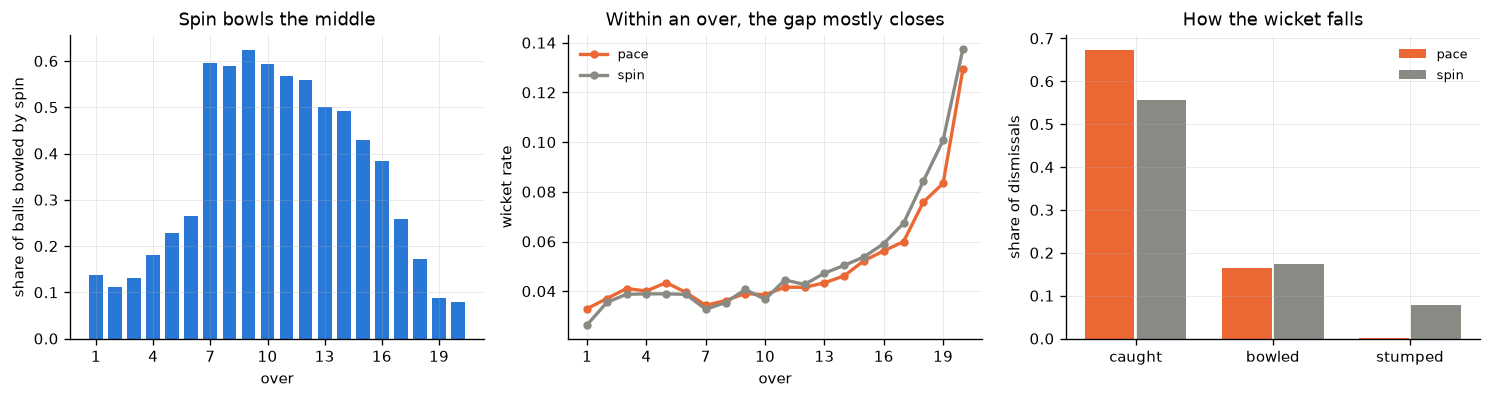

In [17]:
# ---- the raw effect, and the confound that eats it ----
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

spin_share = (df.filter(pl.col("over") < 20).group_by("over")
                .agg((pl.col("bowler_type") == "spin").mean().alias("spin")).sort("over"))
axes[0].bar(spin_share["over"] + 1, spin_share["spin"], color=BLUE, width=0.72)
axes[0].set(xlabel="over", ylabel="share of balls bowled by spin",
            title="Spin bowls the middle", xticks=range(1, 21, 3))

by_over = (df.filter(pl.col("over") < 20).group_by(["over", "bowler_type"])
             .agg(pl.len().alias("n"), pl.col(TARGET).mean().alias("rate"))
             .filter(pl.col("n") >= 300).sort("over"))
for t, colour in [("pace", ORANGE), ("spin", GREY)]:
    v = by_over.filter(pl.col("bowler_type") == t)
    axes[1].plot(v["over"] + 1, v["rate"], "o-", color=colour, lw=2, ms=4, label=t)
axes[1].set(xlabel="over", ylabel="wicket rate", title="Within an over, the gap mostly closes",
            xticks=range(1, 21, 3))
axes[1].legend(frameon=False, fontsize=8)

# stumpings are the one thing only spin does - a tell the target already contains
kinds = (df.filter(pl.col(TARGET) == 1).group_by("bowler_type")
           .agg((pl.col("dismissal_kind") == "stumped").mean().alias("stumped"),
                (pl.col("dismissal_kind") == "bowled").mean().alias("bowled"),
                (pl.col("dismissal_kind") == "caught").mean().alias("caught")))
x = np.arange(3)
for i, (t, colour) in enumerate([("pace", ORANGE), ("spin", GREY)]):
    v = kinds.filter(pl.col("bowler_type") == t)
    axes[2].bar(x + (i - 0.5) * 0.38, [v["caught"][0], v["bowled"][0], v["stumped"][0]],
                width=0.36, color=colour, label=t)
axes[2].set(xticks=x, ylabel="share of dismissals", title="How the wicket falls")
axes[2].set_xticklabels(["caught", "bowled", "stumped"])
axes[2].legend(frameon=False, fontsize=8)
plt.tight_layout()

display(df.group_by("bowler_type").agg(
    pl.len().alias("balls"), pl.col(TARGET).mean().round(4).alias("wicket_rate"),
    # dismissal_kind is null on non-wickets and mean() skips nulls, so this is
    # stumpings as a share of *dismissals*, not of balls
    (pl.col("dismissal_kind") == "stumped").mean().round(4).alias("stumped_share_of_wkts"),
    pl.col("over").mean().round(2).alias("mean_over")).sort("bowler_type"))

In [18]:
# ---- does it help? same 14-feature model, same 5 seeds, one column at a time ----
# frame() above casts only the original CATS, so the new string columns need their own
# vocabulary; everything else is identical to the model in the cell above.
CATS_X = CATS + ["bowler_type", "bowler_arm", "bat_hand"]
levels_x = {**levels,
            **{c: sorted(df[c].unique().drop_nulls().to_list())
               for c in ("bowler_type", "bowler_arm", "bat_hand")}}
MATCHUP = ["bowler_type", "bowler_arm", "bat_hand", "same_handed", "turn_into_batter"]


def frame_x(d, feats):
    X = d.select(feats).to_pandas()
    for c in CATS_X:
        if c in feats:
            X[c] = pd.Categorical(X[c], categories=levels_x[c])
    return X


def ensemble_x(feats, params=NEW, n_seeds=5):
    a, b, c = (frame_x(d, feats) for d in (tr, va, te))
    ps = []
    for s in range(n_seeds):
        m = lgb.LGBMClassifier(**{**params, "random_state": s})
        m.fit(a, ytr, eval_X=b, eval_y=yva, eval_metric="binary_logloss",
              callbacks=[lgb.early_stopping(150, verbose=False)])
        ps.append(m.predict_proba(c)[:, 1])
    return np.mean(ps, axis=0)


rows = []
style_predictions = {}
for name, feats in [("14 features (baseline)", KEEP),
                    ("+ bowler_type", KEEP + ["bowler_type"]),
                    ("+ bowler_type, bat_hand", KEEP + ["bowler_type", "bat_hand"]),
                    ("+ full matchup", KEEP + MATCHUP)]:
    p = ensemble_x(feats)
    style_predictions[name] = p
    ll = log_loss(yte, p)
    rows.append({"model": name, "n_feats": len(feats), "logloss": round(ll, 5),
                 "gain_%": round(100 * (null_ll - ll) / null_ll, 3),
                 "ROC_AUC": round(roc_auc_score(yte, p), 4),
                 "PR_AUC": round(average_precision_score(yte, p), 4)})
display(pl.DataFrame(rows))

model,n_feats,logloss,gain_%,ROC_AUC,PR_AUC
str,i64,f64,f64,f64,f64
"""14 features (baseline)""",14,0.19423,2.334,0.6192,0.0839
"""+ bowler_type""",15,0.1942,2.347,0.6194,0.0841
"""+ bowler_type, bat_hand""",16,0.19423,2.332,0.6192,0.0838
"""+ full matchup""",19,0.19421,2.344,0.6192,0.0838


In [19]:
# Paired uncertainty: resample matches, not individual balls.
old_test = lgbm.predict_proba(Xte)[:, 1]
comparisons = [
    ("pruned vs old 37-feature model", old_test, p_new),
    ("+ batting position vs pruned", p_new, p_pos),
    ("+ bowler type vs pruned", p_new, style_predictions["+ bowler_type"]),
    ("+ full matchup vs pruned", p_new, style_predictions["+ full matchup"]),
]
uncertainty = []
for name, reference, candidate in comparisons:
    ci = clustered_log_loss_gain(
        yte, reference, candidate, te["match_id"].to_numpy(), n_boot=5_000
    )
    uncertainty.append({
        "comparison": name,
        "gain_x1e4": round(10_000 * ci.estimate, 3),
        "95%_low_x1e4": round(10_000 * ci.low, 3),
        "95%_high_x1e4": round(10_000 * ci.high, 3),
    })
display(pl.DataFrame(uncertainty))

comparison,gain_x1e4,95%_low_x1e4,95%_high_x1e4
str,f64,f64,f64
"""pruned vs old 37-feature model""",1.161,-0.751,3.018
"""+ batting position vs pruned""",-0.244,-0.727,0.236
"""+ bowler type vs pruned""",0.264,-0.207,0.726
"""+ full matchup vs pruned""",0.2,-0.538,0.936


Positive values favour the named candidate; the units are $10^{-4}$ log-loss points. A 95%
"
            "interval that crosses zero means the apparent ordering is not stable across matches. This is a
"
            "more demanding and useful check than comparing random seeds on the same fixed test rows.

### What it was worth

| model | log loss | gain over null | ROC-AUC |
|---|---|---|---|
| 14 features (baseline) | 0.19423 | +2.33% | 0.6192 |
| + `bowler_type` | 0.19420 | +2.35% | 0.6194 |
| + `bowler_type`, `bat_hand` | 0.19423 | +2.33% | 0.6192 |
| + full matchup | 0.19421 | +2.34% | 0.6192 |

Nothing here survives the match-clustered uncertainty check. Every 95% interval crosses zero,
including the pruned model versus the original. The simpler 14-feature model remains attractive
for maintainability, but the score ordering should be read as indistinguishable on this sample.

The unconditional pace/spin gap is real: pace takes a wicket on 5.18% of deliveries and spin on
4.55%. It is also heavily confounded by when each type bowls. Once the model already knows the
clock and batter state, bowling type adds no stable incremental wicket signal.

`bat_hand` is useful only as part of a matchup, not as an isolated property. Even the full matchup
does not improve wicket log loss reliably here. The same information is more useful in the run
model, where bowling type changes the outcome distribution more than it changes the marginal
probability of a dismissal.

One important caveat on the dismissal-type chart: stumpings describe *how* a wicket fell, which is
known only afterwards. They are shown for interpretation and are not used as model inputs.

### Where that leaves the next steps

1. `wicket_bowler` as the target, separating bowler-caused dismissals from run-outs.
2. A rolling-origin evaluation across seasons, with feature choices made before each holdout.
3. Delivery or shot information; the current state features cannot distinguish two otherwise
   similar balls whose physical execution differs by a few centimetres.